# Thai Classical Music — N-gram Baseline Generation (ลาว)

Statistical baseline for comparison against the LSTM model.
Uses a trigram language model with Laplace smoothing conditioned on motif class.

**Same evaluation pipeline as `Khmer_Stage3_Generation_Baseline_LSTM_structured.ipynb`** — produces an identical 6-metric batch CSV for direct comparison.


## 0. Prerequisites & Setup

- Same normalized symbolic dataset as the LSTM notebook (Stage 2 output)
- Pitch-only representation, octave stripped
- REST token included as `<REST_k>` (k = 1–4)

**Goal:** Train a trigram language model per motif class and evaluate on the same 6 metrics as the LSTM baseline.


In [1]:
!pip install -q mido python-rtmidi tqdm



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [2]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf


In [ ]:
# Uncomment on first Colab run:
# !git clone https://github.com/GetomG/Thai-Music-Thesis.git
# %cd Thai-Music-Thesis
# If already cloned:
# !cd Thai-Music-Thesis && git pull


In [3]:
from thai_music_utils.notation_utils import (
    flatten_song_notation, normalize_octave_markers, notation_to_sequence
)
from thai_music_utils.octave_inference import (
    is_thai_note, get_fixed_octave,
    guess_octaves_with_constraints, add_octaves_respecting_labels
)
from thai_music_utils.preprocessing import (
    flatten_song_data, remove_all_signs
)
from thai_music_utils.eda_symbolic_normalization import (
    normalize_token as _eda_normalize,
    normalize_bar, flatten_song,
    THAI_NOTES, UP_MARK, LOW_MARK, REST_TOKEN
)
from thai_music_utils.eda_stats import (
    extract_symbols, pitch_stats, stats_to_df
)
from thai_music_utils.io_utils import save_json_bar_per_line
from thai_music_utils.midi_ranad import generate_ranad_midi

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.font_manager.fontManager.addfont("thsarabunnew-webfont.ttf")
mpl.rc("font", family="TH Sarabun New")
mpl.rcParams["axes.unicode_minus"] = False

import copy, re, math, json
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path
import sys, os

print("✅ Imports OK")


✅ Imports OK


### 0.1 Data Intake


In [4]:
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_ROOT = Path("/content/drive/MyDrive/thai_music_data")
else:
    DATA_ROOT = Path(os.path.abspath("")).resolve() / "thai_music_data"

print(f"Runtime  : {'Colab' if IS_COLAB else 'Local'}")
print(f"DATA_ROOT: {DATA_ROOT}")


Runtime  : Local
DATA_ROOT: /Users/thanakrit/Documents/Thai Music Thesis/thai_music_data


In [5]:
BASE = DATA_ROOT / "songs"
songs = []

for motif_dir in BASE.iterdir():
    if not motif_dir.is_dir():
        continue
    motif = motif_dir.name
    for song_dir in motif_dir.iterdir():
        json_dir = song_dir / "json"
        if not json_dir.exists():
            continue
        for json_file in json_dir.glob("*.json"):
            try:
                with open(json_file, "r", encoding="utf-8") as f:
                    data = json.load(f)
                songs.append({"motif": motif, "song": song_dir.name,
                               "path": str(json_file), "data": data})
            except Exception as e:
                print(f"⚠️ Skipped {json_file}: {e}")

print(f"Total songs loaded: {len(songs)}")
by_motif = defaultdict(int)
for s in songs:
    by_motif[s["motif"]] += 1
for motif, n in sorted(by_motif.items()):
    print(f"  {motif}: {n}")


Total songs loaded: 44
  จีน: 4
  พม่า: 5
  ลาว: 18
  เขมร: 7
  แขก: 8
  ไทยเดิม: 2


In [7]:
songs = [s for s in songs if s["motif"] == "ลาว"]
print("Total Laos songs:", len(songs))


Total Laos songs: 18


### 0.2 Symbolic Normalization & Sequence Construction

Identical to the LSTM notebook — same `normalize_token` and `song_to_pitch_sequence` functions.


In [8]:
THAI_NOTES = set("ดรมฟซลท")
UP_MARK    = "ํ"
LOW_MARK   = "ฺ"

def normalize_token(token):
    """
    Convert token into pitch tokens + compressed rest tokens.
    REST compression: consecutive dashes → <REST_4>, <REST_3>, <REST_2>, <REST_1>
    """
    if not isinstance(token, str):
        return ["<REST_1>"]
    token = token.strip()

    if set(token) == {"-"}:
        dash_count, rests = len(token), []
        while dash_count > 0:
            if dash_count >= 4:   rests.append("<REST_4>"); dash_count -= 4
            elif dash_count >= 3: rests.append("<REST_3>"); dash_count -= 3
            elif dash_count >= 2: rests.append("<REST_2>"); dash_count -= 2
            else:                 rests.append("<REST_1>"); dash_count -= 1
        return rests

    out, i = [], 0
    while i < len(token):
        ch = token[i]
        if ch == "-":
            dash_count = 0
            while i < len(token) and token[i] == "-":
                dash_count += 1; i += 1
            while dash_count > 0:
                if dash_count >= 4:   out.append("<REST_4>"); dash_count -= 4
                elif dash_count >= 3: out.append("<REST_3>"); dash_count -= 3
                elif dash_count >= 2: out.append("<REST_2>"); dash_count -= 2
                else:                 out.append("<REST_1>"); dash_count -= 1
        elif ch in THAI_NOTES:
            out.append(ch); i += 1
            if i < len(token) and token[i] in {UP_MARK, LOW_MARK}:
                i += 1
        else:
            i += 1
    return out if out else ["<REST_1>"]


def song_to_pitch_sequence(song_json):
    """
    Convert full song JSON → one flat pitch/rest token sequence.
    Handles plain tokens, dict blocks (นำ/ตาม), nested lists.
    """
    sequence = []

    def process_token(tok):
        if isinstance(tok, str):
            sequence.extend(normalize_token(tok))
        elif isinstance(tok, dict):
            for key in tok:
                for inner in tok[key]:
                    process_token(inner)
        elif isinstance(tok, list):
            for inner in tok:
                process_token(inner)

    for section in song_json.get("sections", []):
        for bar in section.get("bars", []):
            for tok in bar:
                process_token(tok)
    return sequence


# ── Apply to all songs ────────────────────────────────────
for s in songs:
    s["pitch_sequence"] = song_to_pitch_sequence(s["data"])

print(f"Sequences built for {len(songs)} songs.")
print(f"Example ({songs[0]['song']}): {songs[0]['pitch_sequence'][:20]}")


Sequences built for 18 songs.
Example (ลาวกระทบไม้): ['<REST_3>', 'ซ', 'ล', 'ท', 'ด', 'ร', '<REST_4>', 'ซ', 'ม', 'ร', 'ม', '<REST_2>', 'ร', 'ด', 'ร', 'ม', 'ด', 'ร', '<REST_4>', '<REST_3>']


### 0.3 Vocabulary


In [8]:
all_tokens = [tok for s in songs for tok in s["pitch_sequence"]]
vocab      = sorted(set(all_tokens))
vocab_size = len(vocab)

print(f"Vocab: {vocab}")
print(f"Vocab size: {vocab_size}")
print(f"Total tokens in corpus: {len(all_tokens)}")


Vocab: ['<REST_1>', '<REST_2>', '<REST_3>', '<REST_4>', 'ซ', 'ด', 'ท', 'ฟ', 'ม', 'ร', 'ล']
Vocab size: 11
Total tokens in corpus: 5936


## 1️⃣ N-gram Language Model

A **trigram LM with Laplace smoothing** conditioned on motif class.

**How it works:**
- Build a frequency table: `count(token | prev_1, prev_2)` for every 3-token sequence in the corpus
- At generation time: given context `(prev_1, prev_2)`, compute
$$P(t \mid \text{ctx}) = \frac{\text{count}(\text{ctx}, t) + \alpha}{\sum_{t'} [\text{count}(\text{ctx}, t') + \alpha]} = \frac{\text{count}(\text{ctx}, t) + \alpha}{\text{count}(\text{ctx}) + \alpha \cdot |V|}$$
- `α = 0.01` by default — small enough to not dominate, large enough to handle unseen contexts

This applies equally for bigram (n=2) or quadgram (n=4) — just change `n`.


In [9]:
def build_ngram_lm(songs, motif, n=3):
    """
    Build an n-gram language model for a given motif.

    Returns:
        lm  — dict {context_tuple: Counter(next_token)}
            context length = n-1 tokens
    """
    lm = defaultdict(Counter)
    for song in songs:
        if song["motif"] != motif:
            continue
        seq = song["pitch_sequence"]
        for i in range(len(seq) - n + 1):
            ctx      = tuple(seq[i : i + n - 1])
            next_tok = seq[i + n - 1]
            lm[ctx][next_tok] += 1
    return lm


def lm_stats(lm, n):
    """Print summary statistics about a built language model."""
    total_ngrams = sum(sum(c.values()) for c in lm.values())
    unique_ctx   = len(lm)
    print(f"n={n} LM stats:")
    print(f"  Unique {n-1}-token contexts : {unique_ctx:,}")
    print(f"  Total {n}-gram observations : {total_ngrams:,}")
    # top 10 most-common contexts
    top = sorted(lm.items(), key=lambda x: sum(x[1].values()), reverse=True)[:10]
    print(f"  Top 10 contexts by frequency:")
    for ctx, cnt in top:
        total = sum(cnt.values())
        top_next = cnt.most_common(3)
        print(f"    {ctx} → {total:4d} obs  |  {top_next}")


In [10]:
# Build trigram LM (default used throughout the notebook)
lm3 = build_ngram_lm(songs, motif="เขมร", n=3)
lm_stats(lm3, n=3)

print()
lm2 = build_ngram_lm(songs, motif="เขมร", n=2)
lm_stats(lm2, n=2)

print()
lm4 = build_ngram_lm(songs, motif="เขมร", n=4)
lm_stats(lm4, n=4)


n=3 LM stats:
  Unique 2-token contexts : 93
  Total 3-gram observations : 5,922
  Top 10 contexts by frequency:
    ('ด', 'ร') →  254 obs  |  [('ฟ', 110), ('ด', 80), ('ม', 19)]
    ('ซ', 'ฟ') →  222 obs  |  [('ร', 93), ('ซ', 47), ('<REST_1>', 31)]
    ('<REST_1>', 'ล') →  221 obs  |  [('<REST_1>', 86), ('ด', 39), ('ซ', 25)]
    ('ร', 'ด') →  220 obs  |  [('ล', 108), ('ร', 52), ('ด', 27)]
    ('ล', 'ซ') →  217 obs  |  [('ฟ', 143), ('ล', 28), ('ด', 21)]
    ('ซ', 'ล') →  215 obs  |  [('ด', 78), ('ซ', 69), ('<REST_1>', 33)]
    ('<REST_1>', 'ฟ') →  213 obs  |  [('<REST_1>', 88), ('<REST_3>', 33), ('<REST_2>', 29)]
    ('ฟ', 'ซ') →  207 obs  |  [('ล', 104), ('<REST_1>', 45), ('ฟ', 36)]
    ('ด', '<REST_1>') →  201 obs  |  [('ร', 88), ('ล', 55), ('ฟ', 31)]
    ('ฟ', 'ร') →  197 obs  |  [('ด', 65), ('ฟ', 44), ('<REST_1>', 42)]

n=2 LM stats:
  Unique 1-token contexts : 11
  Total 2-gram observations : 5,929
  Top 10 contexts by frequency:
    ('<REST_1>',) → 1007 obs  |  [('ล', 221), ('ฟ', 

## 2️⃣ Generation

`generate_from_fragment_ngram` mirrors the LSTM `generate_from_fragment` interface exactly:
- Input: raw fragment slot list (Thai notation strings)
- Output: `generated_tokens` list (seed + new tokens) — same format expected by `postprocess_generated`

**Seed:** last `n-1` tokens from the normalized fragment are used as the initial context window.  
**Sampling:** Laplace-smoothed multinomial — reproducible via `seed=`.


In [11]:
def generate_from_fragment_ngram(
    fragment_tokens,
    lm,
    vocab,
    n=3,
    max_new_tokens=240,
    alpha=0.01,
    bar_size=32,
    seed=None,
):
    """
    Generate a continuation from a raw Thai slot-notation fragment using
    an n-gram language model with Laplace smoothing.

    Args:
        fragment_tokens — list of slot strings (e.g. ["----", "---ฟ", ...])
        lm              — n-gram LM built by build_ngram_lm()
        vocab           — sorted list of all tokens (from Section 0.3)
        n               — n-gram order (2=bigram, 3=trigram, 4=quadgram)
        max_new_tokens  — number of new tokens to generate
        alpha           — Laplace smoothing coefficient
        bar_size        — slots per bar for pretty-printing (default 32)
        seed            — RNG seed for reproducibility

    Returns:
        generated_tokens — list of token strings: seed (n-1 tokens) + new tokens
                           Same format as LSTM generate_from_fragment output.
                           Pass seq_len=n-1 to postprocess_generated.
    """
    rng = np.random.default_rng(seed)
    V   = len(vocab)

    # ── 1. Normalize fragment → flat token list ───────────
    normalized = []
    for tok in fragment_tokens:
        normalized.extend(normalize_token(tok))

    # ── 2. Build seed context (last n-1 tokens) ──────────
    ctx_len = n - 1
    if len(normalized) < ctx_len:
        pad        = ["<REST_1>"] * (ctx_len - len(normalized))
        normalized = pad + normalized
    seed_toks = normalized[-ctx_len:]   # list of n-1 tokens
    context   = tuple(seed_toks)

    # ── 3. Generate max_new_tokens ────────────────────────
    generated = list(seed_toks)         # seed + new appended here

    for _ in range(max_new_tokens):
        counts = lm.get(context, Counter())
        probs  = np.array([(counts.get(tok, 0) + alpha) for tok in vocab], dtype=float)
        probs /= probs.sum()

        idx      = int(rng.choice(V, p=probs))
        next_tok = vocab[idx]
        generated.append(next_tok)

        if ctx_len > 0:
            context = (*context[1:], next_tok)

    # ── 4. Pretty-print generated continuation ────────────
    pretty_stream = []
    for t in generated[ctx_len:]:       # skip seed prefix
        if t.startswith("<REST_"):
            k = int(t.replace("<REST_", "").replace(">", ""))
            pretty_stream.extend(["-"] * k)
        else:
            pretty_stream.append(t)

    print(f"\nGENERATED continuation (n={n}, α={alpha}):\n")
    for i in range(0, len(pretty_stream), bar_size):
        bar     = pretty_stream[i : i + bar_size]
        grouped = ["".join(bar[j : j + 4]) for j in range(0, len(bar), 4)]
        print(", ".join(grouped))

    return generated

print("✅ generate_from_fragment_ngram defined")


✅ generate_from_fragment_ngram defined


### 2.1 Fragment Demo

Same fragment as the LSTM notebook for a side-by-side comparison.


In [12]:
# ── Demo config ───────────────────────────────────────────
DEMO_N          = 3       # n-gram order (2=bigram, 3=trigram, 4=quadgram)
DEMO_ALPHA      = 0.01    # Laplace smoothing coefficient
DEMO_SEED       = 25      # same seed as LSTM demo for comparability
DEMO_MAX_TOKENS = 240     # ≈ 30 bars


In [13]:
# Same fragment as LSTM notebook (เขมร-style, 2 bars)
fragment = [
    "----", "---ฟ", "-ฟฟฟ", "-ฟ-ฟ", "---ซ", "---ล", "---ดํ", "---รํ",
    "-ฟํ-ดํ", "-รํ-ฟํ", "-ลํซํฟํ", "-ดํ-รํ", "ฟํรํดํล", "-ดํ--", "-ซ-ล", "ดํซลดํ", "----",
]


In [14]:
lm_demo = {2: lm2, 3: lm3, 4: lm4}[DEMO_N]

generated_tokens = generate_from_fragment_ngram(
    fragment_tokens=fragment,
    lm=lm_demo,
    vocab=vocab,
    n=DEMO_N,
    max_new_tokens=DEMO_MAX_TOKENS,
    alpha=DEMO_ALPHA,
    seed=DEMO_SEED,
)



GENERATED continuation (n=3, α=0.01):

----, --ซ-, ฟลซด, รฟร-, ---ซ, ลดรฟ, ซฟซ-, ล---
----, ----, ร-ด-, ฟ---, -ดร-, ด-ร-, ร-ฟ-, ----
----, ม-ม-, ม-ม-, ม-ม-, ม-ม-, ม-ม-, ม-ม-, ม-มร
ดลซฟ, มดรด, ดด-ซ, ----, ----, -ฟ--, ดฟร-, --ดร
ดลซล, -ซ-ฟ, --ลด, รฟซฟ, ร-ฟฟ, ฟฟฟฟ, ฟ-ฟ-, ด-ฟฟ
ฟด-ล, -ลซซ, --ฟร, ฟ-ซฟ, -ล-ด, -ร-ฟ, ซ-ล-, ----
ด--ฟ, ฟฟฟ-, ร-ฟ-, --ด-, รรมฟ, ซ-ฟ-, -ฟฟฟ, ฟดฟร
มฟซฟ, รดลด, รฟรร, รร--, --ดล, ซฟ-ฟ, --ฟล, -ล--
ลซฟซ, ลดลซ, ฟรฟฟ, ฟ-ด-, ล--ร, รรมฟ, รดรฟ, ร-


## 3️⃣ Post-processing & MIDI Export

Run `postprocess_generated` to combine the fragment and continuation, infer octaves via DP, and produce `combined_slots`.  
Pass `verbose=True` to inspect the full octave-annotated song JSON.  
Then export to MIDI with `generate_ranad_midi`.

> **N-gram note:** pass `seq_len=DEMO_N-1` (not 32) — the N-gram generator seeds on `n-1` tokens, not a 32-token window.

In [15]:
def combine_fragment_and_generated(
    fragment_tokens,
    generated_tokens,
    normalize_token,
    seq_len=16
):
    """
    Combine original fragment (preserving octave marks)
    with generated continuation.

    Returns dash-based slot list.
    """

    # -----------------------------
    # 1️⃣ Keep fragment EXACTLY as is
    # -----------------------------
    fragment_slots = fragment_tokens.copy()

    # -----------------------------
    # 2️⃣ Remove seed duplication from generated
    # -----------------------------
    continuation = generated_tokens[seq_len:]

    # -----------------------------
    # 3️⃣ Convert generated tokens back to dash string
    # -----------------------------
    generated_parts = []

    for tok in continuation:
        if tok.startswith("<REST_"):
            k = int(tok.replace("<REST_", "").replace(">", ""))
            generated_parts.append("-" * k)
        else:
            generated_parts.append(tok)

    generated_string = "".join(generated_parts)

    # -----------------------------
    # 4️⃣ Split generated part into 4-char slots
    # -----------------------------
    generated_slots = [
        generated_string[i:i+4]
        for i in range(0, len(generated_string), 4)
    ]

    # -----------------------------
    # 5️⃣ Combine fragment + generated
    # -----------------------------
    combined_slots = fragment_slots + generated_slots

    return combined_slots


def slots_to_song_data(slots, title="Generated"):

    bars = [
        slots[i:i+8]
        for i in range(0, len(slots), 8)
    ]

    return {
        "title": title,
        "sections": [
            {
                "name": "Generated",
                "bars": bars
            }
        ]
    }


def postprocess_generated(fragment, generated_tokens, seq_len=16, verbose=False):
    """
    Full post-processing pipeline after generation:
      combine → song JSON → DP octave inference → re-flatten

    Args:
        fragment         — original input slot list (raw Thai notation)
        generated_tokens — raw output from generate_from_fragment_ngram
        seq_len          — seed window length to skip when combining (use n-1 for N-gram)
        verbose          — if True, pprint the octave-inferred song JSON

    Returns:
        combined_slots  — flat slot list with octave marks (ready for eval / MIDI export)
        song_data_auto  — full song JSON after octave inference
    """
    # Combine fragment + generated continuation into flat slot list
    combined = combine_fragment_and_generated(fragment, generated_tokens, normalize_token, seq_len)

    # Wrap into song JSON structure (8 slots per bar)
    song_data = slots_to_song_data(combined)

    # Infer octaves via DP smoothness constraint
    song_data_auto = add_octaves_respecting_labels(song_data)

    # Re-flatten back to slot list
    combined_slots = []
    for sec in song_data_auto["sections"]:
        for bar in sec["bars"]:
            if isinstance(bar, list):
                combined_slots.extend(bar)

    print(f"✅ Post-processing done — {len(combined_slots)} slots  ({len(combined_slots) // 32} bars)")

    if verbose:
        from pprint import pprint
        pprint(song_data_auto, width=120, sort_dicts=False)

    return combined_slots, song_data_auto

In [16]:
# ============================================================
# Eval Config — set the reference song for all single-example metrics
# ============================================================
EVAL_SONG = "เขมรพวง"

In [17]:
combined_slots, song_data_auto = postprocess_generated(
    fragment,
    generated_tokens,
    seq_len=DEMO_N - 1,   # ← N-gram: seed is n-1 tokens, not 32
    verbose=False         # set True to inspect octave-annotated JSON
)

✅ Post-processing done — 89 slots  (2 bars)


In [18]:
sequence_string = "".join(combined_slots)

# ============================================================
# Convert Thai octave marks to numeric tags before MIDI export
# ============================================================
import re

LOW_DOT  = "ฺ"   # octave 1
HIGH_DOT = "ํ"   # octave 3

sequence_string = re.sub(rf"([ดรมฟซลท]){LOW_DOT}",  r"\g<1>1", sequence_string)
sequence_string = re.sub(rf"([ดรมฟซลท]){HIGH_DOT}", r"\g<1>3", sequence_string)

midi_out = DATA_ROOT / "generated_ngram.mid" if not IS_COLAB else "/content/generated_ngram.mid"

generate_ranad_midi(
    sequence=sequence_string,
    output_path=str(midi_out),
    bpm=150,
    global_transpose=12,
    play_in_octave_pairs=True,
    enable_roll=True
)

print("✅ MIDI exported successfully →", midi_out)

✅ MIDI exported successfully → /Users/thanakrit/Documents/Thai Music Thesis/thai_music_data/generated_ngram.mid


## 4️⃣ Evaluation

Compare the N-gram generated output against a reference song from the corpus.  
All metrics normalize `combined_slots` using the same `normalize_token` logic as training.  
The same 6 metrics are used as the LSTM notebook so results are directly comparable.

In [19]:
# ============================================================
# Shared setup for evaluation metrics 4.1 – 4.7
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

THAI_PITCHES  = ["ด", "ร", "ม", "ฟ", "ซ", "ล", "ท"]
PITCH_IDX     = {p: i for i, p in enumerate(THAI_PITCHES)}
SLOTS_PER_BAR = 8   # 8 × 4-char slots per bar

# ---------- shared helpers ----------

def _slots_to_pitch_tokens(slots, normalize_token):
    """Normalize a slot list and return only pitch tokens (REST_k filtered out)."""
    tokens = []
    for slot in slots:
        tokens.extend(normalize_token(slot))
    return [t for t in tokens if t in PITCH_IDX]


def _seq_to_pitch_tokens(seq):
    """Extract pitch-only tokens from an already-normalized sequence."""
    return [t for t in seq if t in PITCH_IDX]


def _interval_dist(pitch_tokens):
    """Normalized interval distribution from a pitch-only token list."""
    ivs   = [PITCH_IDX[pitch_tokens[i + 1]] - PITCH_IDX[pitch_tokens[i]]
             for i in range(len(pitch_tokens) - 1)]
    total = len(ivs)
    counts = Counter(ivs)
    return {k: v / total for k, v in counts.items()} if total > 0 else {}


def build_corpus_ngram_set(songs, motif, n):
    """
    Build the set of all unique n-gram types from every song in `songs`
    whose motif matches `motif`.
    """
    corpus = set()
    for song in songs:
        if song.get("motif") != motif:
            continue
        seq = song["pitch_sequence"]
        for i in range(len(seq) - n + 1):
            corpus.add(tuple(seq[i:i + n]))
    return corpus

print("✅ Shared eval helpers loaded (4.1–4.7)")

✅ Shared eval helpers loaded (4.1–4.7)


### 4.1 REST Type Distribution

Compares the proportion of `<REST_1>` / `<REST_2>` / `<REST_3>` / `<REST_4>` between the original song and the generated output.  
A good model should produce a similar rhythmic density profile.

In [20]:
def evaluate_rest_type_distribution_from_slots(combined_slots, song_name, songs, normalize_token):
    """
    Compare REST_1/2/3/4 distribution between:
    - Original song (pitch_sequence)
    - Generated combined_slots (fragment + continuation)
    """
    song_match = None
    for s in songs:
        if s["song"] == song_name:
            song_match = s
            break

    if not song_match:
        print(f"❌ Song '{song_name}' not found.")
        return

    original_tokens = song_match["pitch_sequence"]

    generated_tokens = []
    for slot in combined_slots:
        normalized = normalize_token(slot)
        generated_tokens.extend(normalized)

    rest_types = ["<REST_1>", "<REST_2>", "<REST_3>", "<REST_4>"]

    def get_distribution(tokens):
        total_rests = sum(1 for t in tokens if t.startswith("<REST"))
        counts = {r: 0 for r in rest_types}
        for t in tokens:
            if t in counts:
                counts[t] += 1
        proportions = {
            r: (counts[r] / total_rests if total_rests > 0 else 0)
            for r in rest_types
        }
        return counts, proportions, total_rests

    orig_counts, orig_props, orig_total = get_distribution(original_tokens)
    gen_counts,  gen_props,  gen_total  = get_distribution(generated_tokens)

    print("\n" + "="*70)
    print(f"🎵 REST TYPE DISTRIBUTION — {song_name}")
    print("="*70)

    print("\nOriginal Song:")
    print(f"Total REST tokens: {orig_total}")
    for r in rest_types:
        print(f"{r}: {orig_counts[r]:4d} ({orig_props[r]*100:5.1f}%)")

    print("\nGenerated (Fragment + Continuation):")
    print(f"Total REST tokens: {gen_total}")
    for r in rest_types:
        print(f"{r}: {gen_counts[r]:4d} ({gen_props[r]*100:5.1f}%)")

    print("\nAbsolute Proportion Differences:")
    for r in rest_types:
        diff = abs(gen_props[r] - orig_props[r])
        print(f"{r}: {diff*100:5.1f}%")

    print("="*70 + "\n")

    return {"original": orig_props, "generated": gen_props}


evaluate_rest_type_distribution_from_slots(
    combined_slots, EVAL_SONG, songs, normalize_token
)


🎵 REST TYPE DISTRIBUTION — เขมรพวง

Original Song:
Total REST tokens: 277
<REST_1>:  176 ( 63.5%)
<REST_2>:   30 ( 10.8%)
<REST_3>:   29 ( 10.5%)
<REST_4>:   42 ( 15.2%)

Generated (Fragment + Continuation):
Total REST tokens: 98
<REST_1>:   67 ( 68.4%)
<REST_2>:   13 ( 13.3%)
<REST_3>:    8 (  8.2%)
<REST_4>:   10 ( 10.2%)

Absolute Proportion Differences:
<REST_1>:   4.8%
<REST_2>:   2.4%
<REST_3>:   2.3%
<REST_4>:   5.0%



{'original': {'<REST_1>': 0.6353790613718412,
  '<REST_2>': 0.10830324909747292,
  '<REST_3>': 0.10469314079422383,
  '<REST_4>': 0.15162454873646208},
 'generated': {'<REST_1>': 0.6836734693877551,
  '<REST_2>': 0.1326530612244898,
  '<REST_3>': 0.08163265306122448,
  '<REST_4>': 0.10204081632653061}}

### 4.2 N-gram Overlap

Measures what fraction of the generated n-grams (bigram / trigram / 4-gram) also appear in the reference song.  
Higher overlap → the model is reproducing known melodic patterns.

In [21]:
def evaluate_ngram_overlap(combined_slots, song_name, songs, normalize_token, n=3):
    """
    Compute n-gram overlap between:
    - Original song
    - Generated (fragment + continuation)
    n = 2 (bigram), 3 (trigram), 4 (quadgram)
    """
    song_match = None
    for s in songs:
        if s["song"] == song_name:
            song_match = s
            break

    if not song_match:
        print(f"❌ Song '{song_name}' not found.")
        return

    original_tokens = song_match["pitch_sequence"]

    generated_tokens = []
    for slot in combined_slots:
        generated_tokens.extend(normalize_token(slot))

    def build_ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    orig_ngrams = set(build_ngrams(original_tokens, n))
    gen_ngrams  = build_ngrams(generated_tokens, n)

    if not gen_ngrams:
        print("⚠️ No generated n-grams.")
        return

    overlap_count = sum(1 for g in gen_ngrams if g in orig_ngrams)
    overlap_ratio = overlap_count / len(gen_ngrams)

    print("\n" + "="*70)
    print(f"🎵 {n}-GRAM OVERLAP — {song_name}")
    print("="*70)
    print(f"Generated {n}-grams: {len(gen_ngrams)}")
    print(f"Overlap count: {overlap_count}")
    print(f"Overlap ratio: {overlap_ratio:.3f} ({overlap_ratio*100:.1f}%)")
    print("="*70 + "\n")

    return overlap_ratio


evaluate_ngram_overlap(combined_slots, EVAL_SONG, songs, normalize_token, n=2)
evaluate_ngram_overlap(combined_slots, EVAL_SONG, songs, normalize_token, n=3)
evaluate_ngram_overlap(combined_slots, EVAL_SONG, songs, normalize_token, n=4)


🎵 2-GRAM OVERLAP — เขมรพวง
Generated 2-grams: 294
Overlap count: 280
Overlap ratio: 0.952 (95.2%)


🎵 3-GRAM OVERLAP — เขมรพวง
Generated 3-grams: 293
Overlap count: 248
Overlap ratio: 0.846 (84.6%)


🎵 4-GRAM OVERLAP — เขมรพวง
Generated 4-grams: 292
Overlap count: 186
Overlap ratio: 0.637 (63.7%)



0.636986301369863

### 4.3 Pitch KL Divergence

$KL(P \| Q)$ where $P$ = pitch distribution of the reference song and $Q$ = pitch distribution of the generated output.  
Lower KL → closer match in overall pitch preference.

In [22]:
def evaluate_pitch_kl(combined_slots, song_name, songs, normalize_token):
    """
    Compute KL divergence between pitch distributions
    of original song and generated output.
    """
    song_match = None
    for s in songs:
        if s["song"] == song_name:
            song_match = s
            break

    if not song_match:
        print(f"❌ Song '{song_name}' not found.")
        return

    original_tokens = song_match["pitch_sequence"]

    generated_tokens = []
    for slot in combined_slots:
        generated_tokens.extend(normalize_token(slot))

    def get_pitch_distribution(tokens):
        pitch_tokens = [t for t in tokens if t in THAI_PITCHES]
        total  = len(pitch_tokens)
        counts = Counter(pitch_tokens)
        probs  = np.array([
            counts[p] / total if total > 0 else 0
            for p in THAI_PITCHES
        ])
        return probs

    P = get_pitch_distribution(original_tokens)
    Q = get_pitch_distribution(generated_tokens)

    epsilon = 1e-8
    P = P + epsilon
    Q = Q + epsilon

    kl_div = float(np.sum(P * np.log(P / Q)))

    print("\n" + "="*70)
    print(f"🎵 PITCH KL DIVERGENCE — {song_name}")
    print("="*70)
    print("Original distribution:", np.round(P, 3))
    print("Generated distribution:", np.round(Q, 3))
    print(f"\nKL(P || Q): {kl_div:.4f}")
    print("="*70 + "\n")

    return kl_div


evaluate_pitch_kl(combined_slots, EVAL_SONG, songs, normalize_token)


🎵 PITCH KL DIVERGENCE — เขมรพวง
Original distribution: [0.237 0.173 0.019 0.253 0.162 0.152 0.004]
Generated distribution: [0.168 0.183 0.091 0.315 0.122 0.122 0.   ]

KL(P || Q): 0.1201



0.12006605733763165

### 4.4 Interval Distribution

Compares the distribution of melodic step-sizes between consecutive non-rest pitch tokens.  
Thai classical style is dominated by stepwise motion (`±1`, `±2`); large leaps are rare.

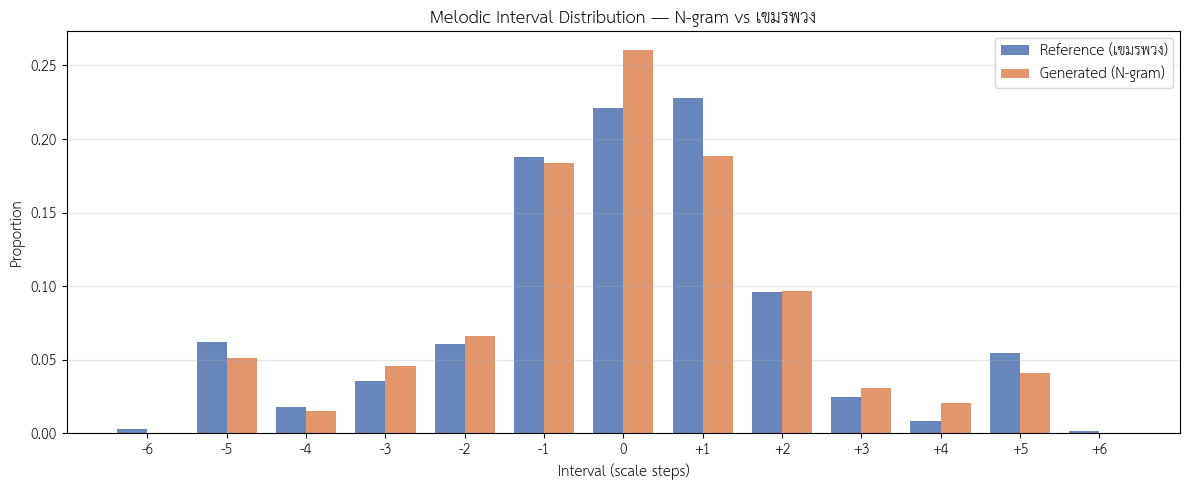


  Interval     Reference     Generated
--------------------------------------
        -6        0.0027        0.0000
        -5        0.0617        0.0510
        -4        0.0178        0.0153
        -3        0.0357        0.0459
        -2        0.0604        0.0663
        -1        0.1879        0.1837
        +0        0.2209        0.2602
        +1        0.2277        0.1888
        +2        0.0960        0.0969
        +3        0.0247        0.0306
        +4        0.0082        0.0204
        +5        0.0549        0.0408
        +6        0.0014        0.0000


{'reference': {0: 0.22085048010973937,
  2: 0.09602194787379972,
  -5: 0.06172839506172839,
  1: 0.22770919067215364,
  -1: 0.18792866941015088,
  -4: 0.01783264746227709,
  5: 0.05486968449931413,
  3: 0.024691358024691357,
  -2: 0.06035665294924554,
  -3: 0.03566529492455418,
  4: 0.00823045267489712,
  -6: 0.0027434842249657062,
  6: 0.0013717421124828531},
 'generated': {0: 0.2602040816326531,
  1: 0.18877551020408162,
  -5: 0.05102040816326531,
  2: 0.09693877551020408,
  -3: 0.04591836734693878,
  -1: 0.1836734693877551,
  -2: 0.0663265306122449,
  5: 0.04081632653061224,
  4: 0.02040816326530612,
  -4: 0.015306122448979591,
  3: 0.030612244897959183}}

In [23]:
def evaluate_interval_distribution(combined_slots, song_name, songs, normalize_token):
    """
    Compare melodic interval distributions between generated output and a reference song.
    Intervals are step differences (scale positions) between consecutive non-rest pitches.
    """
    song_match = next((s for s in songs if s["song"] == song_name), None)
    if not song_match:
        print(f"❌ Song '{song_name}' not found.")
        return

    ref_pitch = _seq_to_pitch_tokens(song_match["pitch_sequence"])
    gen_pitch = _slots_to_pitch_tokens(combined_slots, normalize_token)
    ref_dist  = _interval_dist(ref_pitch)
    gen_dist  = _interval_dist(gen_pitch)

    all_ivs  = sorted(set(ref_dist) | set(gen_dist))
    x        = np.arange(len(all_ivs))
    width    = 0.38

    ref_vals = [ref_dist.get(iv, 0) for iv in all_ivs]
    gen_vals = [gen_dist.get(iv, 0) for iv in all_ivs]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width / 2, ref_vals, width,
           label=f"Reference ({song_name})", color="#4C72B0", alpha=0.85)
    ax.bar(x + width / 2, gen_vals, width,
           label="Generated (N-gram)",       color="#DD8452", alpha=0.85)
    ax.set_xlabel("Interval (scale steps)")
    ax.set_ylabel("Proportion")
    ax.set_title(f"Melodic Interval Distribution — N-gram vs {song_name}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{iv:+d}" if iv != 0 else "0" for iv in all_ivs])
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Interval':>10}  {'Reference':>12}  {'Generated':>12}")
    print("-" * 38)
    for iv in all_ivs:
        print(f"{iv:>+10}  {ref_dist.get(iv, 0):>12.4f}  {gen_dist.get(iv, 0):>12.4f}")

    return {"reference": ref_dist, "generated": gen_dist}


evaluate_interval_distribution(combined_slots, EVAL_SONG, songs, normalize_token)

### 4.5 Repetition Score

`score = (total n-grams − unique n-grams) / total n-grams`  
`0` = all unique; `1` = entirely looping.  
The per-segment line plot reveals *where* repetition clusters — a common failure mode at longer generation lengths.


🔁 3-GRAM REPETITION SCORE
Generated : 0.4676  (46.8% of 3-grams are repeats)
Reference : 0.7692  (76.9%)


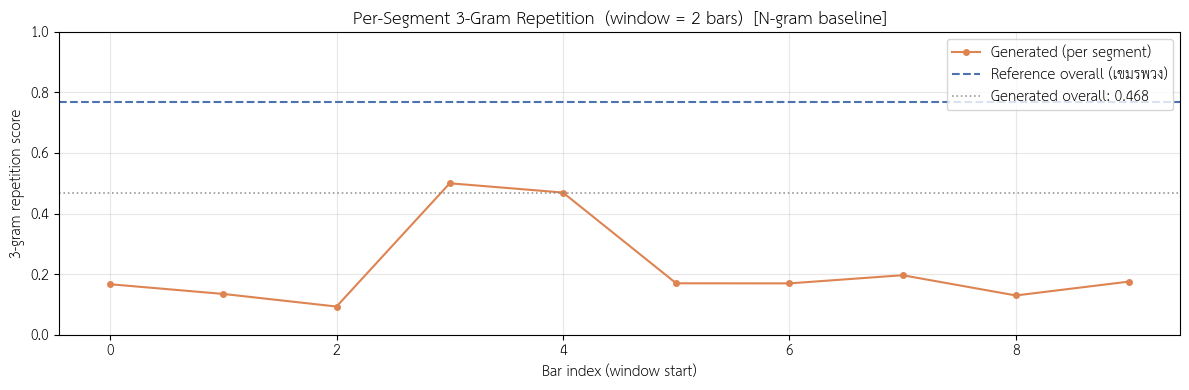

{'generated': 0.46757679180887374,
 'reference': 0.7691542288557214,
 'per_segment': [(0, 0.16666666666666666),
  (1, 0.1346153846153846),
  (2, 0.09302325581395349),
  (3, 0.5),
  (4, 0.46938775510204084),
  (5, 0.16981132075471697),
  (6, 0.1694915254237288),
  (7, 0.19642857142857142),
  (8, 0.12962962962962962),
  (9, 0.17543859649122806)]}

In [24]:
def compute_repetition_score(slots, normalize_token, n=3):
    """
    Repetition score = proportion of n-grams that are duplicates.
      score = (total - unique) / total  =  1 - type-token ratio
    0 = all unique; 1 = entirely looping.
    """
    tokens = []
    for slot in slots:
        tokens.extend(normalize_token(slot))
    ngrams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    if not ngrams:
        return 0.0
    counts          = Counter(ngrams)
    duplicate_count = sum(c - 1 for c in counts.values())
    return duplicate_count / len(ngrams)


def evaluate_repetition_score(combined_slots, song_name, songs, normalize_token,
                               n=3, window_bars=2):
    """
    Compute and compare overall repetition scores, then plot per-segment scores.
    """
    gen_score = compute_repetition_score(combined_slots, normalize_token, n)

    ref_score  = None
    song_match = next((s for s in songs if s["song"] == song_name), None)
    if song_match:
        ref_slots = []
        for sec in song_match.get("sections", []):
            for bar in sec.get("bars", []):
                if isinstance(bar, list):
                    ref_slots.extend(bar)
        if ref_slots:
            ref_score = compute_repetition_score(ref_slots, normalize_token, n)
        else:
            seq = song_match["pitch_sequence"]
            ngrams = [tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)]
            if ngrams:
                counts    = Counter(ngrams)
                ref_score = sum(c - 1 for c in counts.values()) / len(ngrams)

    print("\n" + "=" * 60)
    print(f"🔁 {n}-GRAM REPETITION SCORE")
    print("=" * 60)
    print(f"Generated : {gen_score:.4f}  ({gen_score * 100:.1f}% of {n}-grams are repeats)")
    if ref_score is not None:
        print(f"Reference : {ref_score:.4f}  ({ref_score * 100:.1f}%)")
    print("=" * 60)

    window_slots = SLOTS_PER_BAR * window_bars
    scores, bar_positions = [], []
    for start in range(0, len(combined_slots) - window_slots + 1, SLOTS_PER_BAR):
        window = combined_slots[start:start + window_slots]
        scores.append(compute_repetition_score(window, normalize_token, n))
        bar_positions.append(start // SLOTS_PER_BAR)

    if scores:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(bar_positions, scores, marker="o", linewidth=1.5, markersize=4,
                color="#DD8452", label="Generated (per segment)")
        if ref_score is not None:
            ax.axhline(ref_score, color="#4C72B0", linestyle="--", linewidth=1.5,
                       label=f"Reference overall ({song_name})")
        ax.axhline(gen_score, color="grey", linestyle=":", linewidth=1.2, alpha=0.8,
                   label=f"Generated overall: {gen_score:.3f}")
        ax.set_xlabel("Bar index (window start)")
        ax.set_ylabel(f"{n}-gram repetition score")
        ax.set_title(f"Per-Segment {n}-Gram Repetition  (window = {window_bars} bars)  [N-gram baseline]")
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.show()

    return {
        "generated"   : gen_score,
        "reference"   : ref_score,
        "per_segment" : list(zip(bar_positions, scores)),
    }


evaluate_repetition_score(combined_slots, EVAL_SONG, songs, normalize_token, n=3, window_bars=2)

### 4.6 Corpus N-Gram Overlap

Like 4.2, but the **reference set is the union of all เขมร songs** — not a single reference.  
Avoids circularity and gives a truer picture of stylistic in-distribution-ness for the whole motif.  
Reported for n = 2, 3, 4 with a summary bar chart.


📚 CORPUS 2-GRAM OVERLAP  —  motif: เขมร  (7 songs)
Corpus 2-gram types  : 93
Generated 2-grams   : 294
Overlap count         : 284
Overlap ratio         : 0.9660  (96.6%)

📚 CORPUS 3-GRAM OVERLAP  —  motif: เขมร  (7 songs)
Corpus 3-gram types  : 469
Generated 3-grams   : 293
Overlap count         : 265
Overlap ratio         : 0.9044  (90.4%)

📚 CORPUS 4-GRAM OVERLAP  —  motif: เขมร  (7 songs)
Corpus 4-gram types  : 1,189
Generated 4-grams   : 292
Overlap count         : 218
Overlap ratio         : 0.7466  (74.7%)


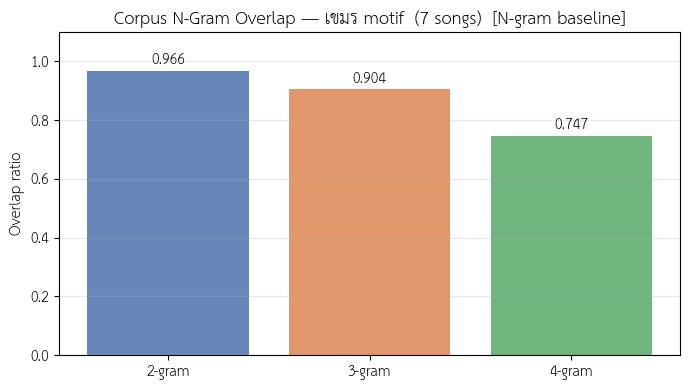

{2: 0.9659863945578231, 3: 0.9044368600682594, 4: 0.7465753424657534}

In [25]:
def evaluate_corpus_ngram_overlap(combined_slots, songs, normalize_token, motif="เขมร", n=3):
    """
    Compute n-gram overlap between generated output and the full corpus of `motif`.
    Reference set = union of all pitch_sequence n-gram types for that motif.
    """
    corpus_ngrams = build_corpus_ngram_set(songs, motif=motif, n=n)

    gen_tokens = []
    for slot in combined_slots:
        gen_tokens.extend(normalize_token(slot))
    gen_ngrams = [tuple(gen_tokens[i:i + n]) for i in range(len(gen_tokens) - n + 1)]

    if not gen_ngrams:
        print("⚠️ No generated n-grams.")
        return None

    overlap_count  = sum(1 for g in gen_ngrams if g in corpus_ngrams)
    overlap_ratio  = overlap_count / len(gen_ngrams)
    corpus_n_songs = sum(1 for s in songs if s.get("motif") == motif)

    print(f"\n{'=' * 68}")
    print(f"📚 CORPUS {n}-GRAM OVERLAP  —  motif: {motif}  ({corpus_n_songs} songs)")
    print(f"{'=' * 68}")
    print(f"Corpus {n}-gram types  : {len(corpus_ngrams):,}")
    print(f"Generated {n}-grams   : {len(gen_ngrams):,}")
    print(f"Overlap count         : {overlap_count:,}")
    print(f"Overlap ratio         : {overlap_ratio:.4f}  ({overlap_ratio * 100:.1f}%)")
    print(f"{'=' * 68}")

    return overlap_ratio


def evaluate_corpus_ngram_all_n(combined_slots, songs, normalize_token, motif="เขมร"):
    """Run corpus n-gram overlap for n = 2, 3, 4 and plot a summary bar chart."""
    ns     = [2, 3, 4]
    ratios = [
        evaluate_corpus_ngram_overlap(combined_slots, songs, normalize_token,
                                      motif=motif, n=n) or 0.0
        for n in ns
    ]

    colors = ["#4C72B0", "#DD8452", "#55A868"]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar([f"{n}-gram" for n in ns], ratios, color=colors, alpha=0.85)
    for bar, val in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Overlap ratio")
    corpus_n_songs = sum(1 for s in songs if s.get("motif") == motif)
    ax.set_title(f"Corpus N-Gram Overlap — {motif} motif  ({corpus_n_songs} songs)  [N-gram baseline]")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dict(zip(ns, ratios))


evaluate_corpus_ngram_all_n(combined_slots, songs, normalize_token, motif="เขมร")

### 4.7 Segment Decay Analysis

Slides a 1-bar window across `combined_slots` and plots its n-gram overlap with the เขมร corpus at each bar position.  
- **Flat line** → model stays in-style throughout.  
- **Declining trend** → model drifts out-of-distribution over time (common with long generation).  
The green dotted line marks the end of the input fragment, where free generation begins.

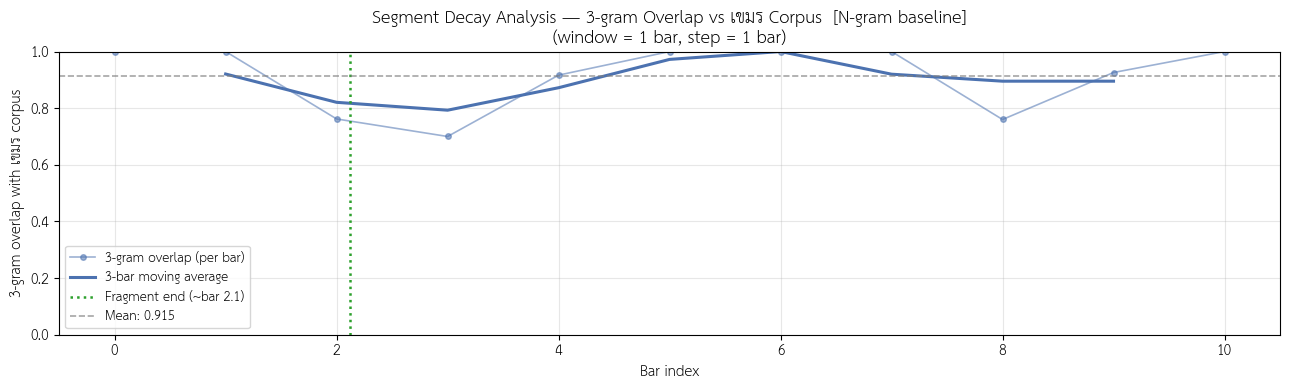


Mean overlap : 0.9150
Min  at bar 3 : 0.7000
Max  at bar 0 : 1.0000


{'bar_indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'overlaps': [1.0,
  1.0,
  0.7619047619047619,
  0.7,
  0.9166666666666666,
  1.0,
  1.0,
  1.0,
  0.76,
  0.9259259259259259,
  1.0],
 'mean': 0.9149543049543049}

In [26]:
def evaluate_segment_decay(combined_slots, songs, normalize_token,
                           motif="เขมร", n=3,
                           segment_bars=1, step_bars=1,
                           fragment=None):
    """
    Sliding-window n-gram overlap against the corpus, plotted across bar positions.
    Visualises whether the model stays in-distribution as the sequence progresses.
    """
    segment_slots = SLOTS_PER_BAR * segment_bars
    step_slots    = SLOTS_PER_BAR * step_bars

    corpus_ngrams = build_corpus_ngram_set(songs, motif=motif, n=n)

    bar_indices, overlaps = [], []
    for start in range(0, len(combined_slots) - segment_slots + 1, step_slots):
        window     = combined_slots[start:start + segment_slots]
        win_tokens = []
        for slot in window:
            win_tokens.extend(normalize_token(slot))
        win_ngrams = [tuple(win_tokens[i:i + n]) for i in range(len(win_tokens) - n + 1)]
        if not win_ngrams:
            continue
        overlap = sum(1 for g in win_ngrams if g in corpus_ngrams) / len(win_ngrams)
        overlaps.append(overlap)
        bar_indices.append(start // SLOTS_PER_BAR)

    if not overlaps:
        print("⚠️ Not enough data for segment decay plot.")
        return {}

    mean_overlap     = float(np.mean(overlaps))
    fragment_end_bar = len(fragment) / SLOTS_PER_BAR if fragment is not None else None

    if len(overlaps) >= 3:
        smoothed = np.convolve(overlaps, np.ones(3) / 3, mode="valid")
        smooth_x = bar_indices[1: 1 + len(smoothed)]
    else:
        smoothed, smooth_x = np.array([]), []

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(bar_indices, overlaps, marker="o", linewidth=1.2, markersize=4,
            color="#4C72B0", alpha=0.55, label=f"{n}-gram overlap (per bar)")
    if len(smoothed):
        ax.plot(smooth_x, smoothed, linewidth=2.2, color="#4C72B0",
                label="3-bar moving average")
    if fragment_end_bar is not None:
        ax.axvline(fragment_end_bar, color="#2ca02c", linestyle=":",
                   linewidth=1.8, label=f"Fragment end (~bar {fragment_end_bar:.1f})")
    ax.axhline(mean_overlap, color="grey", linestyle="--", linewidth=1.2, alpha=0.7,
               label=f"Mean: {mean_overlap:.3f}")
    ax.set_xlabel("Bar index")
    ax.set_ylabel(f"{n}-gram overlap with {motif} corpus")
    ax.set_title(
        f"Segment Decay Analysis — {n}-gram Overlap vs {motif} Corpus  [N-gram baseline]\n"
        f"(window = {segment_bars} bar, step = {step_bars} bar)"
    )
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    argmin = int(np.argmin(overlaps))
    argmax = int(np.argmax(overlaps))
    print(f"\nMean overlap : {mean_overlap:.4f}")
    print(f"Min  at bar {bar_indices[argmin]} : {overlaps[argmin]:.4f}")
    print(f"Max  at bar {bar_indices[argmax]} : {overlaps[argmax]:.4f}")

    return {"bar_indices": bar_indices, "overlaps": overlaps, "mean": mean_overlap}


evaluate_segment_decay(
    combined_slots, songs, normalize_token,
    motif="เขมร", n=3,
    segment_bars=1, step_bars=1,
    fragment=fragment
)

## 5️⃣ Batch Evaluation Pipeline

Systematically evaluates the N-gram model across **multiple songs × multiple α values × multiple random seeds**.

Each combination produces a full row of all 6 metrics, collected into a pandas DataFrame.

**Key difference from LSTM batch eval:** temperature is replaced by `alpha` (Laplace smoothing strength) and `n` (n-gram order) as the sweep parameters.

**Pipeline overview:**
1. **5.1 Config** — define test songs, alpha values, seeds, n values
2. **5.2 Runner** — `extract_section_seed`, `run_single_eval_ngram`, `run_batch_eval_ngram`
3. **5.3 Aggregate Table** — group by `(song, n, alpha)`, report mean ± std per metric
4. **5.4 Visualization Suite** — alpha sweep line plots, per-metric heatmap, segment decay overlay, interval distribution grid, repetition rate overlay

### 5.1 Batch Eval Config

- **`BATCH_SONGS`** — songs to evaluate (must exist in `songs`)
- **`BATCH_NS`** — n-gram orders to sweep (2, 3, 4)
- **`BATCH_ALPHAS`** — Laplace smoothing strengths to sweep (analogous to temperature)
- **`BATCH_SEEDS`** — random seeds → mean ± std over N runs
- **`BATCH_MAX_TOKENS`** — generation length per run
- **`BATCH_MOTIF`** — motif label for corpus n-gram functions
- **`BATCH_REF_SONG`** — reference for single-song metrics (4.1–4.3)

In [27]:
# ============================================================
# 5.1  Batch Evaluation Config  (N-gram version)
# ============================================================

BATCH_SONGS = [
    "เขมรพวง",
    "เขมรไทรโยค",
    "เขมรโพธิสัตว์",
    "เขมรลออองค์",
]

# N-gram orders to sweep
BATCH_NS = [2, 3, 4]

# Laplace smoothing α sweep  (analogous to temperature in the LSTM notebook)
BATCH_ALPHAS = [0.001, 0.01, 0.1, 1.0]

# Independent seeds per (song × n × alpha) → mean ± std
BATCH_SEEDS = [42, 43, 44, 45, 46]

# Generation length per run (tokens)
BATCH_MAX_TOKENS = 240   # ≈ 30 bars

# Motif label
BATCH_MOTIF = "เขมร"

# n-gram order for all batch metrics  (use BATCH_NS[1] = 3 as default metric order)
BATCH_N = 3

# Reference song for single-song metrics (REST distribution, n-gram overlap, KL)
BATCH_REF_SONG = "เขมรพวง"

# ── derived ────────────────────────────────────────────────
print(f"Songs  : {len(BATCH_SONGS)}")
print(f"N vals : {BATCH_NS}")
print(f"Alphas : {BATCH_ALPHAS}")
print(f"Seeds  : {len(BATCH_SEEDS)}  →  "
      f"{len(BATCH_SONGS) * len(BATCH_NS) * len(BATCH_ALPHAS) * len(BATCH_SEEDS)} total runs  "
      f"(all sections × combos)")

Songs  : 4
N vals : [2, 3, 4]
Alphas : [0.001, 0.01, 0.1, 1.0]
Seeds  : 5  →  240 total runs  (all sections × combos)


### 5.2 Batch Runner

**`extract_section_seed(song, section_idx)`** — pulls the first bar of a given section as the raw fragment.

**`run_single_eval_ngram(...)`** — one full pipeline pass:  
`extract seed → generate (N-gram) → postprocess (seq_len=n-1) → compute all 6 metrics → return dict`

**`run_batch_eval_ngram(...)`** — outer loop over `songs × all-sections × ns × alphas × seeds`.

> Corpus n-gram set is cached per `(motif, metric_n)` before the loop.

In [28]:
import pandas as pd
from tqdm.auto import tqdm

# ============================================================
# Helper: extract first bar of a section as seed fragment
# ============================================================

def extract_section_seed(song, section_idx=0):
    """
    Return the first bar of song["data"]["sections"][section_idx] as a flat
    list of slot strings.  Handles plain list bars and dict (นำ/ตาม) bars.
    """
    sections = song["data"].get("sections", [])
    if section_idx >= len(sections):
        print(f"⚠️  {song['song']}: section_idx={section_idx} out of range "
              f"({len(sections)} sections)")
        return []

    section  = sections[section_idx]
    bars     = section.get("bars", [])
    if not bars:
        print(f"⚠️  {song['song']} §{section_idx} has no bars.")
        return []

    first_bar = bars[0]

    if isinstance(first_bar, list):
        return [slot for slot in first_bar if isinstance(slot, str)]

    if isinstance(first_bar, dict):
        for key in first_bar:
            val = first_bar[key]
            if isinstance(val, list):
                return [slot for slot in val if isinstance(slot, str)]

    print(f"⚠️  {song['song']} §{section_idx} bar[0] has unrecognised format.")
    return []


# ============================================================
# Helper: KL divergence scalar
# ============================================================

def _kl_scalar(ref_tokens, gen_tokens):
    """KL(P_ref ‖ Q_gen) on 7-note pitch distribution."""
    eps = 1e-8

    def _dist(toks):
        counts = Counter(t for t in toks if t in PITCH_IDX)
        total  = sum(counts.values()) or 1
        return np.array([counts.get(p, 0) / total for p in THAI_PITCHES]) + eps

    return float(np.sum(_dist(ref_tokens) * np.log(_dist(ref_tokens) / _dist(gen_tokens))))


# ============================================================
# Core: single eval run  (N-gram version)
# ============================================================

def run_single_eval_ngram(
    song_name,
    section_idx,
    n,
    alpha,
    seed,
    songs,
    lm,
    vocab,
    normalize_token,
    ref_song_name,
    motif,
    metric_n,
    max_new_tokens,
    corpus_ngram_cache,
):
    """
    One full pipeline pass for the N-gram baseline:
      seed → generate_from_fragment_ngram → postprocess (seq_len=n-1) → 6 metrics

    Returns a flat dict (one DataFrame row), or None on failure.
    """
    song = next((s for s in songs if s["song"] == song_name), None)
    if song is None:
        print(f"❌ Song '{song_name}' not found.")
        return None

    section_name = "?"
    secs = song["data"].get("sections", [])
    if section_idx < len(secs):
        section_name = secs[section_idx].get("name", str(section_idx))

    fragment = extract_section_seed(song, section_idx)
    if not fragment:
        return None

    # ── generate with N-gram LM ────────────────────────────
    gen_tokens = generate_from_fragment_ngram(
        fragment_tokens=fragment,
        lm=lm,
        vocab=vocab,
        n=n,
        max_new_tokens=max_new_tokens,
        alpha=alpha,
        bar_size=32,
        seed=seed,
    )
    if gen_tokens is None:
        return None

    # ── postprocess — use seq_len=n-1 (N-gram seed length) ─
    combined_slots, _ = postprocess_generated(
        fragment, gen_tokens, seq_len=n - 1, verbose=False
    )

    # ── reference song tokens ─────────────────────────────
    ref_song   = next((s for s in songs if s["song"] == ref_song_name), None)
    ref_tokens = ref_song["pitch_sequence"] if ref_song else []

    # ── normalize generated tokens ────────────────────────
    gen_norm = []
    for slot in combined_slots:
        gen_norm.extend(normalize_token(slot))

    # ── Metric 1: REST distribution χ² distance ──────────
    rest_types  = ["<REST_1>", "<REST_2>", "<REST_3>", "<REST_4>"]
    ref_total_r = sum(1 for t in ref_tokens if t.startswith("<REST")) or 1
    gen_total_r = sum(1 for t in gen_norm   if t.startswith("<REST")) or 1

    rest_chi2 = 0.0
    for r in rest_types:
        p = sum(1 for t in ref_tokens if t == r) / ref_total_r
        q = sum(1 for t in gen_norm   if t == r) / gen_total_r
        rest_chi2 += (p - q) ** 2

    # ── Metric 2: single-song n-gram overlap ─────────────
    ref_ngrams = set(
        tuple(ref_tokens[i:i + metric_n])
        for i in range(len(ref_tokens) - metric_n + 1)
    )
    gen_ngrams = [tuple(gen_norm[i:i + metric_n]) for i in range(len(gen_norm) - metric_n + 1)]
    single_overlap = (
        sum(1 for g in gen_ngrams if g in ref_ngrams) / len(gen_ngrams)
        if gen_ngrams else 0.0
    )

    # ── Metric 3: pitch KL divergence ────────────────────
    kl = _kl_scalar(ref_tokens, gen_norm) if ref_tokens else float("nan")

    # ── Metric 4: corpus n-gram overlap ──────────────────
    corpus_set = corpus_ngram_cache.get(metric_n, set())
    corpus_overlap = (
        sum(1 for g in gen_ngrams if g in corpus_set) / len(gen_ngrams)
        if gen_ngrams else 0.0
    )

    # ── Metric 5: overall repetition score ───────────────
    rep_score = compute_repetition_score(combined_slots, normalize_token, n=metric_n)

    # ── Metric 6: segment decay mean ─────────────────────
    seg_window   = SLOTS_PER_BAR
    seg_overlaps = []
    for start in range(0, len(combined_slots) - seg_window + 1, seg_window):
        window   = combined_slots[start:start + seg_window]
        win_toks = []
        for slot in window:
            win_toks.extend(normalize_token(slot))
        win_ng = [tuple(win_toks[i:i + metric_n]) for i in range(len(win_toks) - metric_n + 1)]
        if win_ng:
            seg_overlaps.append(
                sum(1 for g in win_ng if g in corpus_set) / len(win_ng)
            )
    seg_decay_mean = float(np.mean(seg_overlaps)) if seg_overlaps else float("nan")

    return {
        "song"            : song_name,
        "section_idx"     : section_idx,
        "section_name"    : section_name,
        "n"               : n,
        "alpha"           : alpha,
        "seed"            : seed,
        "rest_chi2"       : round(rest_chi2,       6),
        "single_overlap"  : round(single_overlap,  6),
        "pitch_kl"        : round(kl,              6),
        "corpus_overlap"  : round(corpus_overlap,  6),
        "repetition_score": round(rep_score,        6),
        "seg_decay_mean"  : round(seg_decay_mean,  6),
    }

print("✅ run_single_eval_ngram defined")

✅ run_single_eval_ngram defined


In [29]:
def run_batch_eval_ngram(
    batch_songs,
    batch_ns,
    batch_alphas,
    batch_seeds,
    songs,
    lms,           # dict: {n: lm_n}  e.g. {2: lm2, 3: lm3, 4: lm4}
    vocab,
    normalize_token,
    ref_song_name,
    motif,
    metric_n,
    max_new_tokens,
):
    """
    Outer batch loop: songs × all-sections × ns × alphas × seeds.

    Args:
        lms     — pre-built dict of {n: lm} for every n in batch_ns
        metric_n— n-gram order used for evaluation metrics (default BATCH_N = 3)

    Returns a pandas DataFrame with one row per run.
    """
    print(f"Building corpus n-gram set for motif '{motif}', metric_n={metric_n} …")
    corpus_ngram_cache = {metric_n: build_corpus_ngram_set(songs, motif=motif, n=metric_n)}
    print(f"  → {len(corpus_ngram_cache[metric_n]):,} unique {metric_n}-gram types in corpus\n")

    rows = []
    total = (
        sum(len(s["data"].get("sections", [])) for s in songs
            if s["song"] in batch_songs)
        * len(batch_ns)
        * len(batch_alphas)
        * len(batch_seeds)
    )

    with tqdm(total=total, desc="Batch eval (N-gram)") as pbar:
        for song_name in batch_songs:
            song = next((s for s in songs if s["song"] == song_name), None)
            if song is None:
                print(f"⚠️  '{song_name}' not in loaded songs — skipping.")
                continue

            sections = song["data"].get("sections", [])

            for sec_idx in range(len(sections)):
                for n in batch_ns:
                    lm = lms.get(n)
                    if lm is None:
                        print(f"⚠️  No LM found for n={n} — skipping.")
                        pbar.update(len(batch_alphas) * len(batch_seeds))
                        continue
                    for alpha in batch_alphas:
                        for seed in batch_seeds:
                            row = run_single_eval_ngram(
                                song_name          = song_name,
                                section_idx        = sec_idx,
                                n                  = n,
                                alpha              = alpha,
                                seed               = seed,
                                songs              = songs,
                                lm                 = lm,
                                vocab              = vocab,
                                normalize_token    = normalize_token,
                                ref_song_name      = ref_song_name,
                                motif              = motif,
                                metric_n           = metric_n,
                                max_new_tokens     = max_new_tokens,
                                corpus_ngram_cache = corpus_ngram_cache,
                            )
                            if row is not None:
                                rows.append(row)
                            pbar.update(1)

    df = pd.DataFrame(rows)
    print(f"\n✅ Batch complete — {len(df)} rows collected.")
    return df

print("✅ run_batch_eval_ngram defined")

✅ run_batch_eval_ngram defined


### 5.3 Aggregate Results Table

Groups by `(song, n, alpha)` and reports **mean ± std** for every metric.  
A second summary groups by `(n, alpha)` only (all songs pooled) — the primary table for the thesis α-sweep analysis.

In [30]:
METRIC_COLS = [
    "rest_chi2",
    "single_overlap",
    "pitch_kl",
    "corpus_overlap",
    "repetition_score",
    "seg_decay_mean",
]

METRIC_LABELS = {
    "rest_chi2"        : "REST χ² dist ↓",
    "single_overlap"   : f"Single {BATCH_N}-gram overlap ↑",
    "pitch_kl"         : "Pitch KL div ↓",
    "corpus_overlap"   : f"Corpus {BATCH_N}-gram overlap ↑",
    "repetition_score" : "Repetition score ↓",
    "seg_decay_mean"   : "Seg decay mean ↑",
}


def make_aggregate_table(df):
    """
    Print two aggregate tables from the batch eval DataFrame:

    Table A — (song × n × alpha): mean ± std per metric
    Table B — (n × alpha) only (all songs pooled): mean ± std per metric

    Returns (agg_a, agg_b) as DataFrames.
    """
    def fmt(mean, std):
        return f"{mean:.4f} ± {std:.4f}"

    # ── Table A: song × n × alpha ──────────────────────────
    grp_a  = df.groupby(["song", "n", "alpha"])[METRIC_COLS]
    mean_a = grp_a.mean()
    std_a  = grp_a.std(ddof=1).fillna(0)

    rows_a = []
    for (song, n, alpha), m_row in mean_a.iterrows():
        s_row = std_a.loc[(song, n, alpha)]
        entry = {"song": song, "n": n, "alpha": alpha}
        for col in METRIC_COLS:
            entry[METRIC_LABELS[col]] = fmt(m_row[col], s_row[col])
        rows_a.append(entry)

    agg_a = pd.DataFrame(rows_a).set_index(["song", "n", "alpha"])

    print("\n" + "=" * 90)
    print("TABLE A — Mean ± Std per (Song × N × Alpha)")
    print("=" * 90)
    print(agg_a.to_string())

    # ── Table B: n × alpha only ────────────────────────────
    grp_b  = df.groupby(["n", "alpha"])[METRIC_COLS]
    mean_b = grp_b.mean()
    std_b  = grp_b.std(ddof=1).fillna(0)

    rows_b = []
    for (n, alpha), m_row in mean_b.iterrows():
        s_row = std_b.loc[(n, alpha)]
        entry = {"n": n, "alpha": alpha}
        for col in METRIC_COLS:
            entry[METRIC_LABELS[col]] = fmt(m_row[col], s_row[col])
        rows_b.append(entry)

    agg_b = pd.DataFrame(rows_b).set_index(["n", "alpha"])

    print("\n" + "=" * 90)
    print("TABLE B — Mean ± Std per (N × Alpha)  (all songs pooled)")
    print("=" * 90)
    print(agg_b.to_string())

    return agg_a, agg_b

print("✅ make_aggregate_table defined")

✅ make_aggregate_table defined


### 5.4 Visualization Suite

Five plots — all generated from `batch_df`:

1. **Alpha sweep** — line plot of each metric's mean vs alpha, one line per n-gram order, with ± std shading
2. **Per-metric heatmap** — rows = songs, columns = alphas (fixed n=BATCH_N); colour = metric mean
3. **Segment decay overlay** — re-runs decay for one representative run at each alpha on a shared axis
4. **Interval distribution grid** — one bar chart per alpha, reference overlaid in each panel
5. **Repetition rate overlay** — per-segment repetition curves for each alpha on one plot

In [31]:
import matplotlib.pyplot as plt
import numpy as np

_ALPHA_PALETTE = ["#4C72B0", "#55A868", "#DD8452", "#C44E52",
                  "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
_N_PALETTE     = ["#4C72B0", "#DD8452", "#55A868"]


# ── Plot 1: Alpha sweep line plot (one line per n) ──────────

def plot_alpha_sweep(df, metric_cols=None, title_suffix=""):
    """
    For each metric: mean ± std across all songs, plotted vs alpha,
    one line per n-gram order.
    """
    if metric_cols is None:
        metric_cols = METRIC_COLS

    ns     = sorted(df["n"].unique())
    alphas = sorted(df["alpha"].unique())

    ncols = 3
    nrows = -(-len(metric_cols) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), squeeze=False)

    for idx, col in enumerate(metric_cols):
        ax = axes[idx // ncols][idx % ncols]
        for ni, n in enumerate(ns):
            sub  = df[df["n"] == n].groupby("alpha")[col]
            mu   = sub.mean().reindex(alphas).values
            sig  = sub.std(ddof=1).fillna(0).reindex(alphas).values
            color = _N_PALETTE[ni % len(_N_PALETTE)]
            ax.plot(range(len(alphas)), mu, marker="o", linewidth=2,
                    color=color, label=f"n={n}")
            ax.fill_between(range(len(alphas)),
                            mu - sig, mu + sig,
                            alpha=0.15, color=color)
        ax.set_title(METRIC_LABELS.get(col, col), fontsize=10)
        ax.set_xlabel("Alpha (Laplace smoothing)")
        ax.set_xticks(range(len(alphas)))
        ax.set_xticklabels([str(a) for a in alphas])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for idx in range(len(metric_cols), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Alpha Sweep — Mean ± Std per Metric  [N-gram baseline]{title_suffix}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Plot 2: Per-metric heatmap (song × alpha, fixed n) ──────

def plot_metric_heatmap(df, fixed_n=None, metric_cols=None, title_suffix=""):
    """
    One heatmap per metric.  Rows = songs, columns = alphas.
    Values = mean across all sections and seeds for (song, alpha) at fixed n.
    """
    if metric_cols is None:
        metric_cols = METRIC_COLS
    if fixed_n is None:
        fixed_n = BATCH_N

    sub         = df[df["n"] == fixed_n]
    songs_order = sorted(sub["song"].unique())
    alphas_order = sorted(sub["alpha"].unique())
    pivot_data   = sub.groupby(["song", "alpha"])[metric_cols].mean()

    ncols = 3
    nrows = -(-len(metric_cols) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

    for idx, col in enumerate(metric_cols):
        ax  = axes[idx // ncols][idx % ncols]
        mat = np.array([
            [pivot_data.loc[(s, a), col]
             if (s, a) in pivot_data.index else np.nan
             for a in alphas_order]
            for s in songs_order
        ])
        im = ax.imshow(mat, aspect="auto", cmap="YlOrRd_r",
                       vmin=np.nanmin(mat), vmax=np.nanmax(mat))
        ax.set_xticks(range(len(alphas_order)))
        ax.set_xticklabels([str(a) for a in alphas_order], fontsize=9)
        ax.set_yticks(range(len(songs_order)))
        ax.set_yticklabels(songs_order, fontsize=8)
        ax.set_title(METRIC_LABELS.get(col, col), fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        for ri in range(len(songs_order)):
            for ci in range(len(alphas_order)):
                v = mat[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.3f}", ha="center", va="center",
                            fontsize=7,
                            color="white" if v < (np.nanmin(mat) + np.nanmax(mat)) / 2
                            else "black")

    for idx in range(len(metric_cols), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Per-Metric Heatmap — Song × Alpha  (n={fixed_n})  [N-gram baseline]{title_suffix}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Plot 3: Segment decay overlay (one curve per alpha) ──────

def plot_segment_decay_overlay(
    batch_songs, batch_alphas, songs, lm, vocab,
    normalize_token, motif, n, max_new_tokens,
    ref_seed=42, section_idx=0, title_suffix=""
):
    """
    For the first song in batch_songs, re-runs generation at each alpha
    (fixed seed=ref_seed, n=n) and overlays the segment decay curves.
    """
    corpus_set = build_corpus_ngram_set(songs, motif=motif, n=n)

    song_name = batch_songs[0]
    song      = next((s for s in songs if s["song"] == song_name), None)
    if song is None:
        print(f"❌ '{song_name}' not found.")
        return

    fragment = extract_section_seed(song, section_idx)
    if not fragment:
        return

    fig, ax = plt.subplots(figsize=(13, 4))

    for a_idx, alpha in enumerate(batch_alphas):
        color = _ALPHA_PALETTE[a_idx % len(_ALPHA_PALETTE)]

        gen_tokens = generate_from_fragment_ngram(
            fragment_tokens=fragment, lm=lm, vocab=vocab,
            n=n, max_new_tokens=max_new_tokens,
            alpha=alpha, bar_size=32, seed=ref_seed,
        )
        if gen_tokens is None:
            continue

        combined, _ = postprocess_generated(fragment, gen_tokens,
                                            seq_len=n - 1, verbose=False)

        bar_indices, overlaps = [], []
        for start in range(0, len(combined) - SLOTS_PER_BAR + 1, SLOTS_PER_BAR):
            window   = combined[start:start + SLOTS_PER_BAR]
            win_toks = []
            for slot in window:
                win_toks.extend(normalize_token(slot))
            win_ng = [tuple(win_toks[i:i + n]) for i in range(len(win_toks) - n + 1)]
            if win_ng:
                overlaps.append(sum(1 for g in win_ng if g in corpus_set) / len(win_ng))
                bar_indices.append(start // SLOTS_PER_BAR)

        ax.plot(bar_indices, overlaps, linewidth=1.5, alpha=0.8,
                color=color, label=f"α={alpha}")

    frag_end = len(fragment) / SLOTS_PER_BAR
    ax.axvline(frag_end, color="green", linestyle=":", linewidth=1.5,
               label=f"Fragment end (~bar {frag_end:.1f})")
    ax.set_xlabel("Bar index")
    ax.set_ylabel(f"{n}-gram overlap with {motif} corpus")
    ax.set_title(f"Segment Decay Overlay — {song_name}  (n={n}, seed={ref_seed})  [N-gram]{title_suffix}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


# ── Plot 4: Interval distribution grid (one panel per alpha) ─

def plot_interval_distribution_grid(
    batch_songs, batch_alphas, songs, lm, vocab,
    normalize_token, ref_song_name, motif, n, max_new_tokens,
    ref_seed=42, section_idx=0, title_suffix=""
):
    """One grouped bar chart per alpha value."""
    song_name = batch_songs[0]
    song      = next((s for s in songs if s["song"] == song_name), None)
    if song is None:
        return

    fragment  = extract_section_seed(song, section_idx)
    if not fragment:
        return

    ref_song  = next((s for s in songs if s["song"] == ref_song_name), None)
    ref_pitch = _seq_to_pitch_tokens(ref_song["pitch_sequence"]) if ref_song else []
    ref_dist  = _interval_dist(ref_pitch)

    ncols = len(batch_alphas)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, alpha in zip(axes, batch_alphas):
        gen_tokens = generate_from_fragment_ngram(
            fragment_tokens=fragment, lm=lm, vocab=vocab,
            n=n, max_new_tokens=max_new_tokens,
            alpha=alpha, bar_size=32, seed=ref_seed,
        )
        if gen_tokens is None:
            ax.set_title(f"α={alpha}\n(failed)")
            continue

        combined, _ = postprocess_generated(fragment, gen_tokens,
                                            seq_len=n - 1, verbose=False)
        gen_pitch = _slots_to_pitch_tokens(combined, normalize_token)
        gen_dist  = _interval_dist(gen_pitch)

        all_ivs = sorted(set(ref_dist) | set(gen_dist))
        x       = np.arange(len(all_ivs))
        width   = 0.38

        ax.bar(x - width / 2,
               [ref_dist.get(iv, 0) for iv in all_ivs],
               width, color="#4C72B0", alpha=0.8, label="Reference")
        ax.bar(x + width / 2,
               [gen_dist.get(iv, 0) for iv in all_ivs],
               width, color="#DD8452", alpha=0.8, label="Generated")

        ax.set_title(f"α = {alpha}", fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{iv:+d}" if iv != 0 else "0"
                            for iv in all_ivs], fontsize=7)
        ax.set_xlabel("Interval (scale steps)")
        ax.grid(axis="y", alpha=0.3)
        if ax is axes[0]:
            ax.set_ylabel("Proportion")
            ax.legend(fontsize=8)

    fig.suptitle(
        f"Interval Distribution by Alpha — {song_name}  (n={n})  [N-gram]{title_suffix}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# ── Plot 5: Repetition rate overlay (one curve per alpha) ────

def plot_repetition_overlay(
    batch_songs, batch_alphas, songs, lm, vocab,
    normalize_token, motif, n, max_new_tokens,
    ref_seed=42, section_idx=0, window_bars=2, title_suffix=""
):
    """Per-segment repetition score for each alpha, overlaid on one axes."""
    song_name = batch_songs[0]
    song      = next((s for s in songs if s["song"] == song_name), None)
    if song is None:
        return

    fragment     = extract_section_seed(song, section_idx)
    if not fragment:
        return

    window_slots = SLOTS_PER_BAR * window_bars
    fig, ax = plt.subplots(figsize=(13, 4))

    for a_idx, alpha in enumerate(batch_alphas):
        color = _ALPHA_PALETTE[a_idx % len(_ALPHA_PALETTE)]

        gen_tokens = generate_from_fragment_ngram(
            fragment_tokens=fragment, lm=lm, vocab=vocab,
            n=n, max_new_tokens=max_new_tokens,
            alpha=alpha, bar_size=32, seed=ref_seed,
        )
        if gen_tokens is None:
            continue

        combined, _ = postprocess_generated(fragment, gen_tokens,
                                            seq_len=n - 1, verbose=False)

        scores, bar_positions = [], []
        for start in range(0, len(combined) - window_slots + 1, SLOTS_PER_BAR):
            window = combined[start:start + window_slots]
            scores.append(compute_repetition_score(window, normalize_token, n=n))
            bar_positions.append(start // SLOTS_PER_BAR)

        ax.plot(bar_positions, scores, linewidth=1.5, alpha=0.8,
                color=color, label=f"α={alpha}")

    frag_end = len(fragment) / SLOTS_PER_BAR
    ax.axvline(frag_end, color="green", linestyle=":", linewidth=1.5,
               label=f"Fragment end (~bar {frag_end:.1f})")
    ax.set_xlabel("Bar index (window start)")
    ax.set_ylabel(f"{n}-gram repetition score")
    ax.set_title(
        f"Repetition Rate Overlay — {song_name}  "
        f"(n={n}, window={window_bars} bars)  [N-gram]{title_suffix}"
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


print("✅ All 5 visualization functions defined")

✅ All 5 visualization functions defined


### 5.5 Run Batch + Display Results

Run the batch pipeline, print aggregate tables, then render all 5 visualizations.  
Re-run only this section after changing config in 5.1 — no other cell needs to be touched.

In [32]:
# ── Run batch evaluation ───────────────────────────────────
batch_df = run_batch_eval_ngram(
    batch_songs     = BATCH_SONGS,
    batch_ns        = BATCH_NS,
    batch_alphas    = BATCH_ALPHAS,
    batch_seeds     = BATCH_SEEDS,
    songs           = songs,
    lms             = {2: lm2, 3: lm3, 4: lm4},
    vocab           = vocab,
    normalize_token = normalize_token,
    ref_song_name   = BATCH_REF_SONG,
    motif           = BATCH_MOTIF,
    metric_n        = BATCH_N,
    max_new_tokens  = BATCH_MAX_TOKENS,
)

# ── Aggregate tables ───────────────────────────────────────
agg_song_n_alpha, agg_n_alpha = make_aggregate_table(batch_df)

# ── Save raw results to CSV ────────────────────────────────
csv_path = DATA_ROOT / "batch_eval_results_khmer_ngram.csv"
batch_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\n💾 Raw results saved → {csv_path}")

Building corpus n-gram set for motif 'เขมร', metric_n=3 …
  → 469 unique 3-gram types in corpus



Batch eval (N-gram):   0%|          | 0/1620 [00:00<?, ?it/s]


GENERATED continuation (n=2, α=0.001):

รดลด, -ลดร, -ฟซล, ดลซ-, -ฟ-ล, ซล--, --ฟร, ฟ-ฟ-
ดรฟล, ----, ---ฟ, -ซฟ-, -ฟซล, ดซลด, ดซฟ-, ด-ลด
รฟซฟ, -ซฟซ, ฟรดร, ดซ-ฟ, --ดล, ---ด, ซฟซล, ดดล-
ซ-รด, -ฟ-ร, ดดซฟ, ซ-ซล, ฟฟ--, -ลดร, ด---, --ลซ
--ดร, -ลดร, ดรดร, -ฟ-ฟ, ----, -ซฟ-, ลซดร, -ลซล
-ฟซล, ซฟ--, -ดฟซ, -ลท-, ม-ร-, -ฟฟร, -ล-ซ, ฟซลด
ซล--, -ฟ--, -ล-ซ, ฟลทร, ฟรดซ, ลดด-, ร--ล, --ซล
-ดรฟ, -ดรร, ด-ซ-, --ดร, -ฟฟด, -ลดร, -ซลซ, ซฟฟร
--ล-, มฟ-ด, ดลซล, ดดร-, ซ
✅ Post-processing done — 77 slots  (2 bars)

GENERATED continuation (n=2, α=0.001):

ฟ-ซล, ซ--ร, --ดด, ลทด-, ----, --ซซ, ลดมซ, ลซลล
-ซล-, ฟ---, ร-ฟซ, -ฟซซ, ฟซ-ม, -ม-ม, ร--ซ, ซฟด-
ซลซฟ, รฟร-, --ด-, ฟดรฟ, รด-ฟ, รฟฟฟ, รดรซ, ฟซลด
ลซฟฟ, ฟ--ล, -ร--, ----, -ลดซ, ลดดล, ล--ม, -ดรม
ซซซฟ, ฟรฟร, ฟซลซ, ฟฟรด, ฟรดม, รรดด, -ซซ-, ล-ดฟ
ฟ-ซล, ซล-ล, -รฟ-, ซฟซฟ, ฟรดล, ลลซ-, --ล-, ---ด
-ดดด, -ล--, ---ด, -มรด, ดรด-, ฟ-ด-, ดดรม, ฟรรด
-ซลซ, ฟม-ล, ดมฟด, ดฟ-ร, รด-ร, ด-ฟ-, ลซล-, ซลซล
-ดล-, ม-ด-, ร-ฟ
✅ Post-processing done — 75 slots  (2 bars)

GENERATED continuation (n=2, α=0.00

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:50: UserWarning: Glyph 967 (\N{GREEK SMALL LETTER CHI}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:50: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:50: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 967 (\N{GREEK SMALL LETTER CHI}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, 

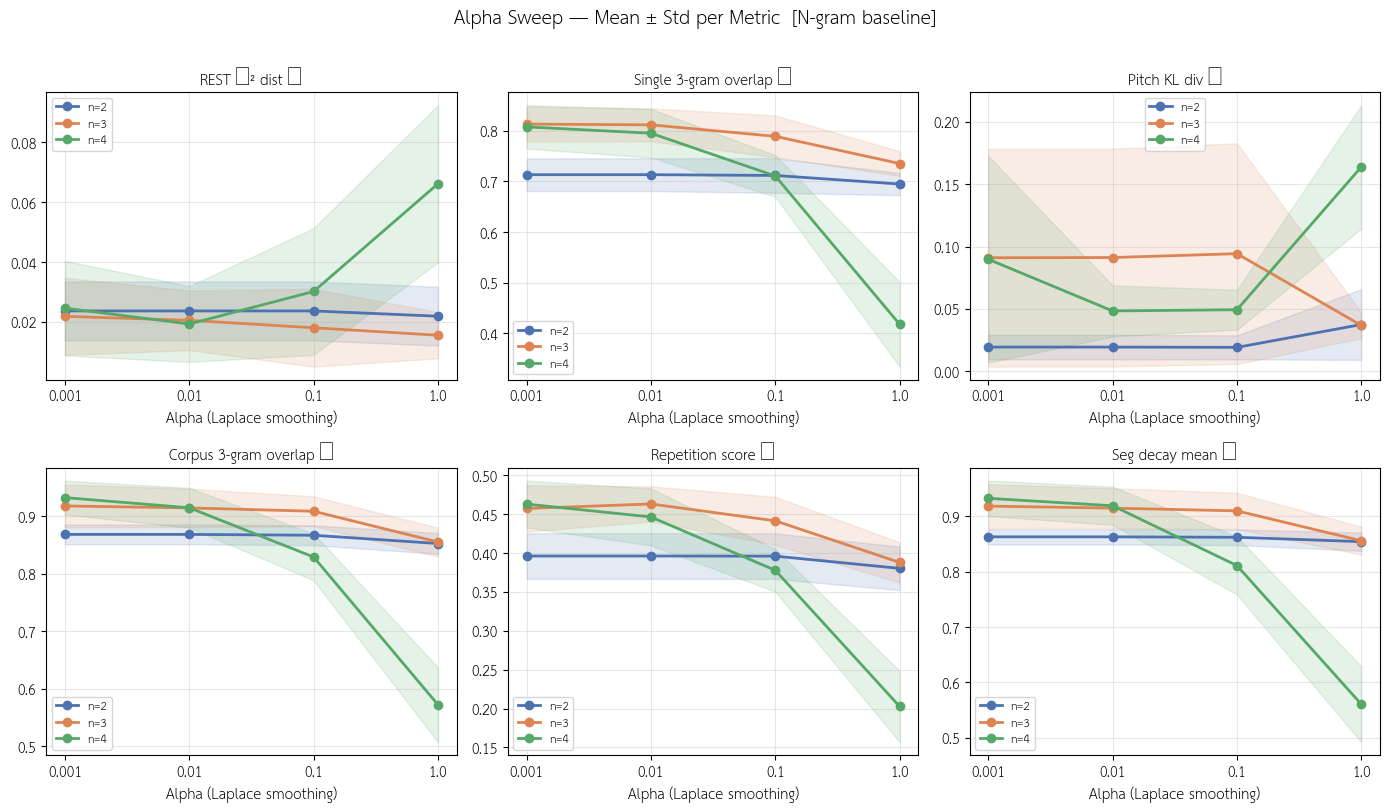

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:106: UserWarning: Glyph 967 (\N{GREEK SMALL LETTER CHI}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:106: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:106: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 967 (\N{GREEK SMALL LETTER CHI}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_i

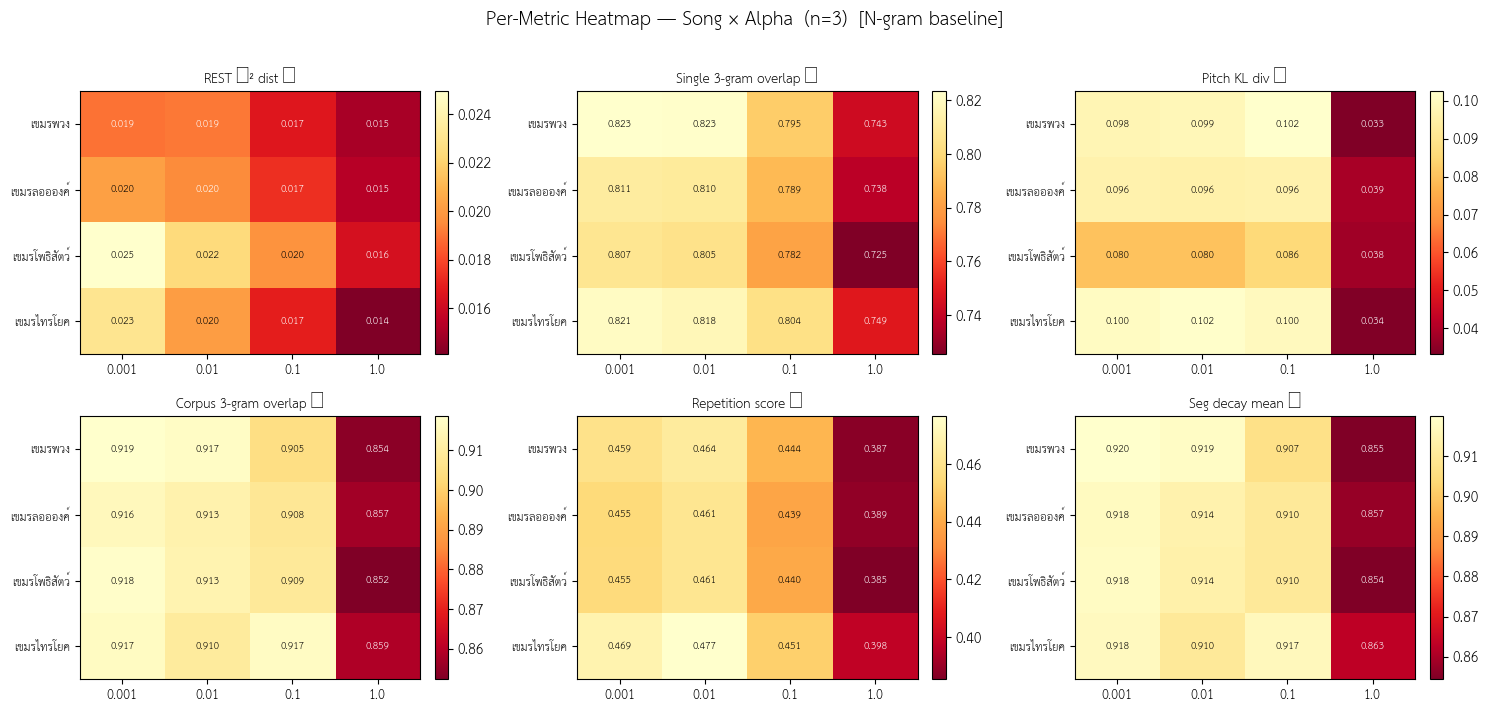


GENERATED continuation (n=3, α=0.001):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซรฟ, ดฟร-, ----, ----
ซ-ลด, รดลด, รดมร, มฟซฟ, ร-รด, ลซฟร, ดดด-, ร-ด-
ร-ร-, -ดร-, ร-ร-, ฟ--ล, ซฟซฟ, รด--, รร-ฟ, -ร-ฟ
----, ดฟร-, -ซลซ, ฟร--, --ฟซ, ลซล-, --ฟล, ซฟรฟ
ซฟรด, ร--ฟ, ฟฟ-ซ, ฟ---, ----, รดฟซ, ลฟซ-, ซ-ด-
--ร-, ----, ----, ม-ม-, มรดร, ฟดลซ, ล-ด-, ด-รร
ดลดร, ฟ-ซ
✅ Post-processing done — 82 slots  (2 bars)

GENERATED continuation (n=3, α=0.01):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซมฟ, ซฟซฟ, รซฟ-, ลดรด
ลดรด, มรมฟ, ซฟร-, รดลซ, ฟรดด, ด-ร-, ด-ร-, ร--ด
ร-ร-, ร-ฟ-, -ลซฟ, ซฟรด, --รร, -ฟ-ร, -ฟ--, --ดฟ
ร--ซ, ลซฟร, ----, ฟซลซ, ล---, ฟลซฟ, รฟซฟ, รดร-
-ฟฟฟ, -ซฟ-, ----, --รด, ฟซลฟ, ซ-ซ-, ด---, ร---
----, --ม-, ม-มร, ดรฟด, ลซล-, ด-ด-, รรดล, ดรฟ-
ซ
✅ Post-processing

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:172: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


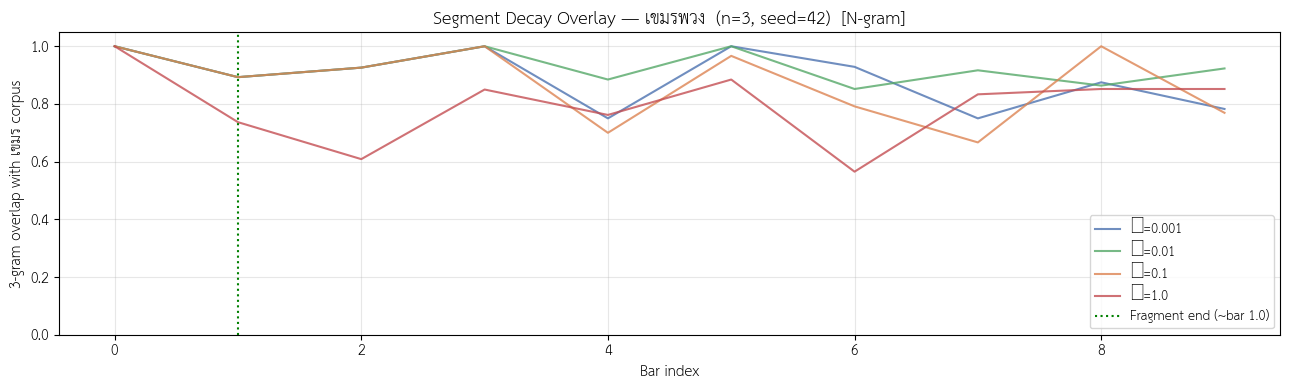


GENERATED continuation (n=3, α=0.001):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซรฟ, ดฟร-, ----, ----
ซ-ลด, รดลด, รดมร, มฟซฟ, ร-รด, ลซฟร, ดดด-, ร-ด-
ร-ร-, -ดร-, ร-ร-, ฟ--ล, ซฟซฟ, รด--, รร-ฟ, -ร-ฟ
----, ดฟร-, -ซลซ, ฟร--, --ฟซ, ลซล-, --ฟล, ซฟรฟ
ซฟรด, ร--ฟ, ฟฟ-ซ, ฟ---, ----, รดฟซ, ลฟซ-, ซ-ด-
--ร-, ----, ----, ม-ม-, มรดร, ฟดลซ, ล-ด-, ด-รร
ดลดร, ฟ-ซ
✅ Post-processing done — 82 slots  (2 bars)

GENERATED continuation (n=3, α=0.01):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซมฟ, ซฟซฟ, รซฟ-, ลดรด
ลดรด, มรมฟ, ซฟร-, รดลซ, ฟรดด, ด-ร-, ด-ร-, ร--ด
ร-ร-, ร-ฟ-, -ลซฟ, ซฟรด, --รร, -ฟ-ร, -ฟ--, --ดฟ
ร--ซ, ลซฟร, ----, ฟซลซ, ล---, ฟลซฟ, รฟซฟ, รดร-
-ฟฟฟ, -ซฟ-, ----, --รด, ฟซลฟ, ซ-ซ-, ด---, ร---
----, --ม-, ม-มร, ดรฟด, ลซล-, ด-ด-, รรดล, ดรฟ-
ซ
✅ Post-processing

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:242: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
/Users/thanakrit/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


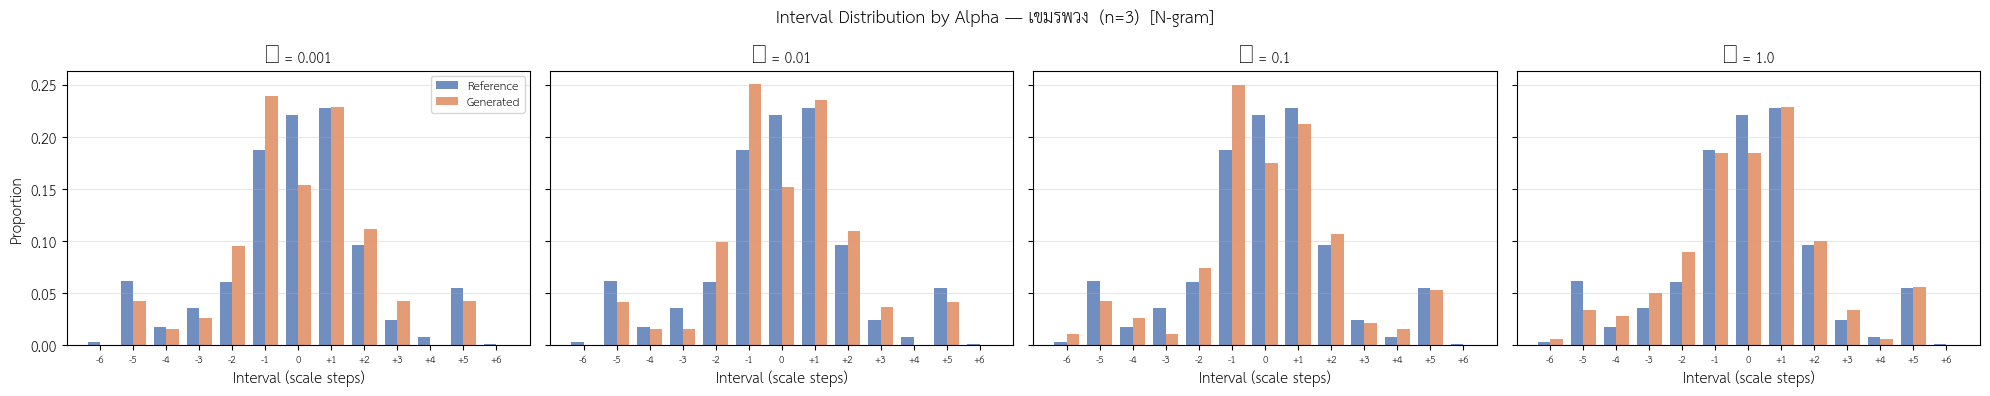


GENERATED continuation (n=3, α=0.001):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซรฟ, ดฟร-, ----, ----
ซ-ลด, รดลด, รดมร, มฟซฟ, ร-รด, ลซฟร, ดดด-, ร-ด-
ร-ร-, -ดร-, ร-ร-, ฟ--ล, ซฟซฟ, รด--, รร-ฟ, -ร-ฟ
----, ดฟร-, -ซลซ, ฟร--, --ฟซ, ลซล-, --ฟล, ซฟรฟ
ซฟรด, ร--ฟ, ฟฟ-ซ, ฟ---, ----, รดฟซ, ลฟซ-, ซ-ด-
--ร-, ----, ----, ม-ม-, มรดร, ฟดลซ, ล-ด-, ด-รร
ดลดร, ฟ-ซ
✅ Post-processing done — 82 slots  (2 bars)

GENERATED continuation (n=3, α=0.01):

ซฟรด, ดรฟฟ, -ฟ-ล, ซฟฟ-, ฟ-ร-, --ฟ-, ลดรด, ร--ซ
ลดลซ, ฟฟ-ซ, -ฟ--, -ฟ--, --ดร, ฟรซฟ, ร-ด-, ลซฟร
ดล-ซ, ---ล, ---ล, ---ด, ---ร, -ฟ-ฟ, ซ---, ด---
ร---, ฟ---, ร-ร-, ซ-ล-, -ซมฟ, ซฟซฟ, รซฟ-, ลดรด
ลดรด, มรมฟ, ซฟร-, รดลซ, ฟรดด, ด-ร-, ด-ร-, ร--ด
ร-ร-, ร-ฟ-, -ลซฟ, ซฟรด, --รร, -ฟ-ร, -ฟ--, --ดฟ
ร--ซ, ลซฟร, ----, ฟซลซ, ล---, ฟลซฟ, รฟซฟ, รดร-
-ฟฟฟ, -ซฟ-, ----, --รด, ฟซลฟ, ซ-ซ-, ด---, ร---
----, --ม-, ม-มร, ดรฟด, ลซล-, ด-ด-, รรดล, ดรฟ-
ซ
✅ Post-processing

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_89628/928634064.py:301: UserWarning: Glyph 945 (\N{GREEK SMALL LETTER ALPHA}) missing from font(s) TH Sarabun New.
  plt.tight_layout()


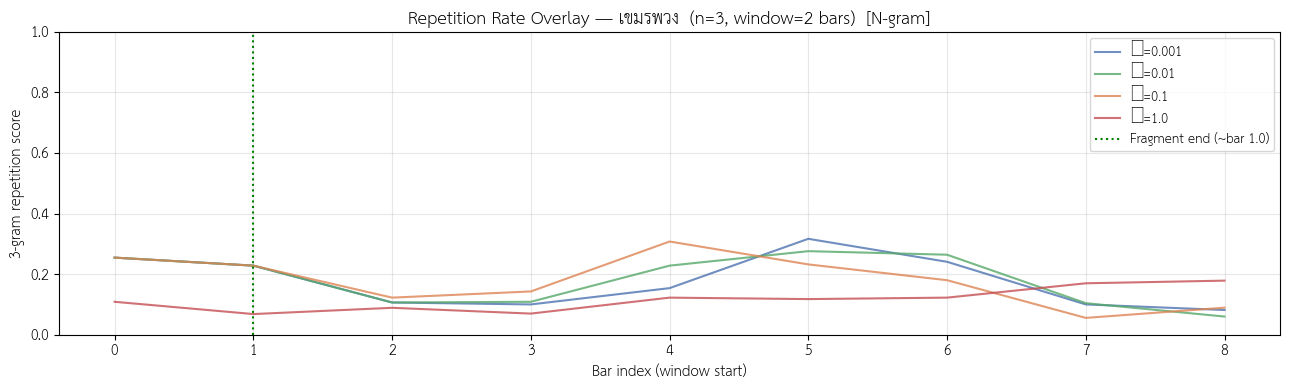

In [33]:
# ── Visualization Suite ────────────────────────────────────
# Shared kwargs for plots 3, 4, 5  (re-generation from scratch)
_viz_kwargs = dict(
    batch_songs     = BATCH_SONGS,
    batch_alphas    = BATCH_ALPHAS,
    songs           = songs,
    lm              = lm3,             # default: trigram LM for viz plots
    vocab           = vocab,
    normalize_token = normalize_token,
    motif           = BATCH_MOTIF,
    n               = BATCH_N,
    max_new_tokens  = BATCH_MAX_TOKENS,
    ref_seed        = BATCH_SEEDS[0],
    section_idx     = 0,
)

# Plot 1 — Alpha sweep (one line per n-gram order)
plot_alpha_sweep(batch_df)

# Plot 2 — Per-metric heatmap (song × alpha, n=BATCH_N)
plot_metric_heatmap(batch_df, fixed_n=BATCH_N)

# Plot 3 — Segment decay overlay (alpha sweep)
plot_segment_decay_overlay(**_viz_kwargs)

# Plot 4 — Interval distribution grid (alpha sweep)
plot_interval_distribution_grid(ref_song_name=BATCH_REF_SONG, **_viz_kwargs)

# Plot 5 — Repetition rate overlay (alpha sweep)
plot_repetition_overlay(window_bars=2, **_viz_kwargs)